In [13]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
import kagglehub
path = kagglehub.dataset_download("ashydv/advertising-dataset")

Using Colab cache for faster access to the 'advertising-dataset' dataset.


In [15]:
print(path)

/kaggle/input/advertising-dataset


In [16]:
print(os.listdir(path))

['advertising.csv']


In [18]:
dataset=pd.read_csv(path+"/advertising.csv")

In [20]:
dataset.shape

(200, 4)

In [21]:
dataset.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [22]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


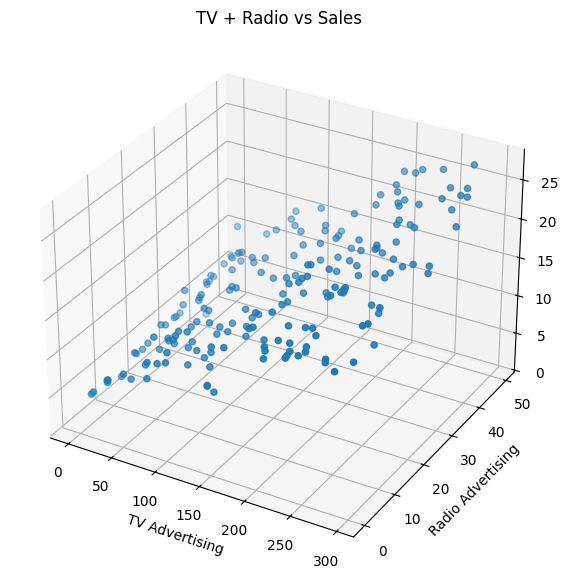

In [25]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    dataset["TV"],
    dataset["Radio"],
    dataset["Sales"]
)

ax.set_xlabel("TV Advertising")
ax.set_ylabel("Radio Advertising")
ax.set_zlabel("Sales")

ax.set_title("TV + Radio vs Sales")

plt.show()

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(dataset[["TV", "Radio"]], dataset["Sales"], test_size=0.2, random_state=42)

In [31]:
lr=LinearRegression()

In [33]:
lr.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred=lr.predict(X_test)

array([16.95537518, 20.36750946, 23.67877906,  9.23932462, 21.8589777 ,
       12.49890184, 21.14158798,  8.71453835, 17.26489488, 16.65891755,
        9.04850144,  8.44326393, 17.92443396,  8.17312478, 12.61199966,
       14.8739442 ,  8.09082502, 17.9679393 , 10.99191604, 20.57101437,
       20.63604288, 12.26621032, 11.0239442 , 22.2361825 ,  9.51268565,
        7.91404079, 20.86878181, 13.8814929 , 10.76286373,  8.05785124,
       15.9504224 , 10.68007267, 20.73382321, 10.22491484, 21.52687927,
       21.3167722 , 12.2771962 , 22.6941923 , 12.69753173,  6.45554633])

In [36]:
lr.coef_

array([0.05450736, 0.10325764])

In [37]:
lr.intercept_

np.float64(4.791381661776025)

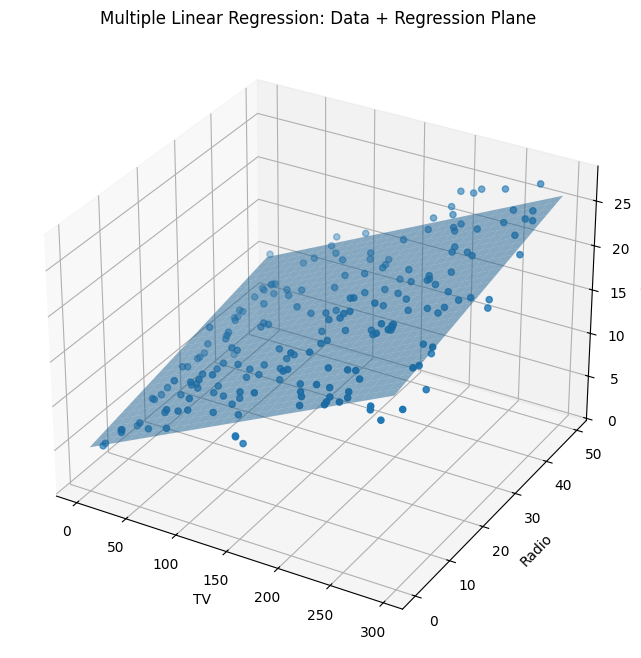

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Actual data points
ax.scatter(
    dataset["TV"],
    dataset["Radio"],
    dataset["Sales"],
    label="Actual Data"
)

# Grid for the plane
tv_range = np.linspace(dataset["TV"].min(), dataset["TV"].max(), 30)
radio_range = np.linspace(dataset["Radio"].min(), dataset["Radio"].max(), 30)

TV, RADIO = np.meshgrid(tv_range, radio_range)

# Prediction using trained model
SALES = (
    lr.coef_[0] * TV
    + lr.coef_[1] * RADIO
    + lr.intercept_
)

# Regression hyperplane
ax.plot_surface(
    TV,
    RADIO,
    SALES,
    alpha=0.5
)

ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")

ax.set_title("Multiple Linear Regression: Data + Regression Plane")

plt.show()

now gradient descent from scratch


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = dataset[["TV", "Radio"]].values
y = dataset["Sales"].values

For easy convergence

In [45]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

In [51]:
class GradientDescent:

    def __init__(self, learning_rate=0.01, epochs=2000):
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.w1 = 0
        self.w2 = 0
        self.b = 0

        self.cost_history = []
    def predict(self, X):
        return (
            self.w1 * X[:, 0]
            + self.w2 * X[:, 1]
            + self.b
        )
    def cost_function(self, y, y_pred):

              n = len(y)

              cost = (1 / (2 * n)) * np.sum((y_pred - y) ** 2)

              return cost
    def fit(self, X, y):

          n = len(y)

          for i in range(self.epochs):

              # Prediction
              y_pred = self.predict(X)

              # Error
              error = y_pred - y

              # Cost
              cost = self.cost_function(y, y_pred)

              self.cost_history.append(cost)

              # Gradients
              dw1 = (1 / n) * np.sum(error * X[:, 0])

              dw2 = (1 / n) * np.sum(error * X[:, 1])

              db = (1 / n) * np.sum(error)

              # Update
              self.w1 = self.w1 - self.learning_rate * dw1

              self.w2 = self.w2 - self.learning_rate * dw2

              self.b = self.b - self.learning_rate * db

In [52]:
model = GradientDescent(
    learning_rate=0.01,
    epochs=2000
)

In [53]:
model.fit(X_scaled, y)

In [54]:
print("w1 =", model.w1)
print("w2 =", model.w2)
print("b =", model.b)

w1 = 4.662972601280731
w2 = 1.5872174299265152
b = 15.130499971800434


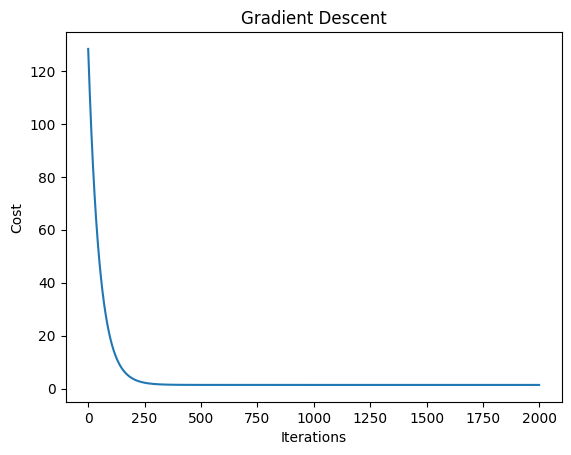

In [55]:
plt.plot(model.cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent")

plt.show()

In [56]:
y_pred = model.predict(X_scaled)

print(y_pred[:10])

[21.21078409 11.26581886 10.48671441 17.30620679 15.6327369  10.34542196
 11.27702063 13.27626612  5.32420711 15.78843566]


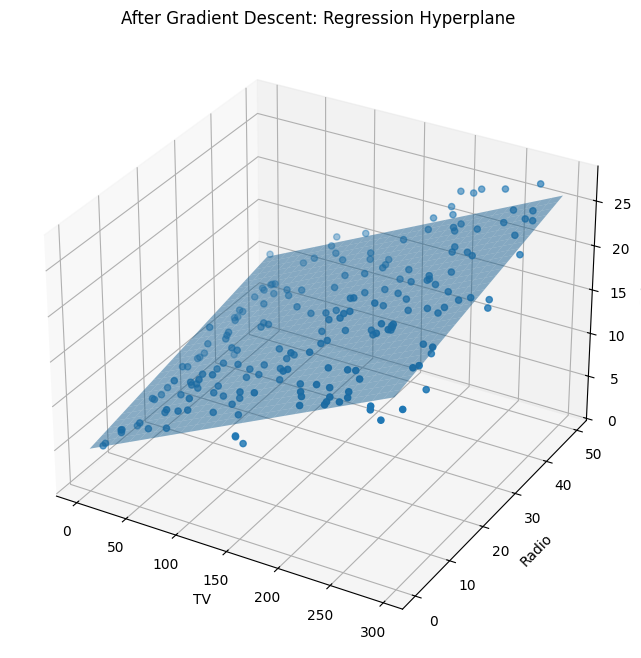

In [57]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection="3d")

# 1. Actual data points
ax.scatter(
    X[:, 0],
    X[:, 1],
    y,
    label="Actual Data"
)

# 2. TV aur Radio ka grid
tv_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
radio_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)

TV, RADIO = np.meshgrid(tv_range, radio_range)

# 3. Grid ko bhi SCALE karna hai
TV_scaled = (TV - X_mean[0]) / X_std[0]
RADIO_scaled = (RADIO - X_mean[1]) / X_std[1]

# 4. GD ke learned parameters se Sales predict karo
SALES = (
    model.w1 * TV_scaled
    + model.w2 * RADIO_scaled
    + model.b
)

# 5. GD ka final plane
ax.plot_surface(
    TV,
    RADIO,
    SALES,
    alpha=0.5
)

ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")

ax.set_title("After Gradient Descent: Regression Hyperplane")

plt.show()

In [58]:
w1_original = model.w1 / X_std[0]
w2_original = model.w2 / X_std[1]

b_original = (
    model.b
    - model.w1 * X_mean[0] / X_std[0]
    - model.w2 * X_mean[1] / X_std[1]
)

print("GD w1:", w1_original)
print("GD w2:", w2_original)
print("GD b :", b_original)

GD w1: 0.05444896060752922
GD w2: 0.1071745717923016
GD b : 4.630879443491714


In [59]:
y_pred_gd = model.predict(X_scaled)

In [62]:
y_pred_lr = lr.predict(X_test)

In [61]:
print(y_pred_gd[:10])
print(y_pred_lr[:10])

[21.21078409 11.26581886 10.48671441 17.30620679 15.6327369  10.34542196
 11.27702063 13.27626612  5.32420711 15.78843566]
[21.2366643  11.27498442 10.46843385 17.3137874  15.76149515 10.31489419
 11.31240547 13.36701624  5.47698601 15.9504224 ]
